CT_PATH: ./patient_0067_svr_diff_l4500_k10_mar3000_beta1_a1.1_b1_repo_logbeta_fdg_ct_ct.nii.gz
REG_PATH: ./patient_0067_svr_diff_l4500_k10_mar3000_beta1_a1.1_b1_repo_logbeta_fdg_ct_regularization_map.nii.gz
CT shape: (128, 128, 384)
Regularization map shape: (128, 128, 384)
Saved figure to: ct_regularization_6x6.png


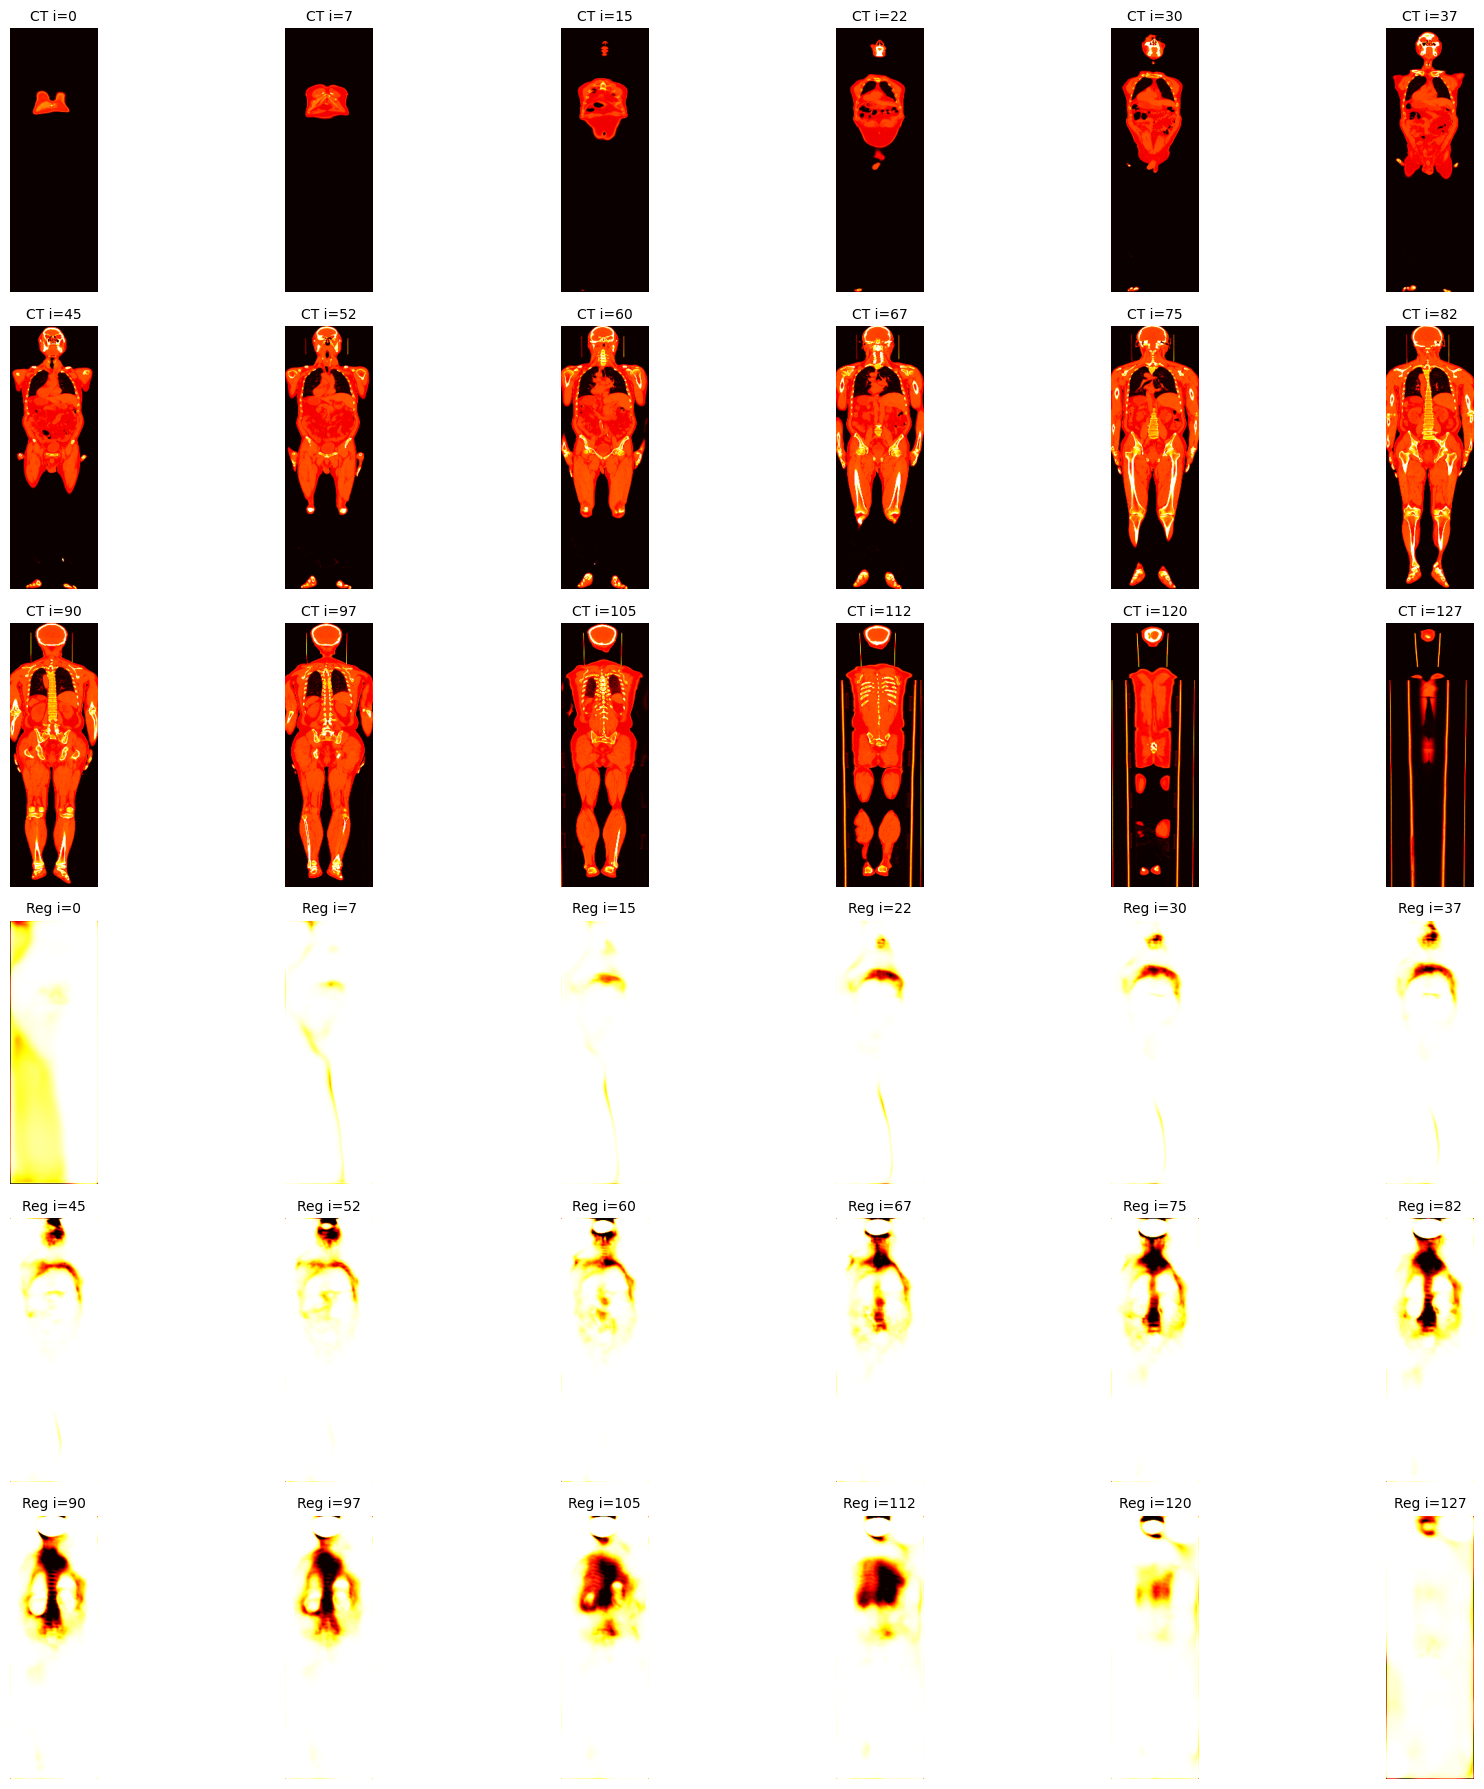

In [5]:
import os
import glob

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt


# ========= 手动设置 =========
INPUT_DIR = "./"   # 如果文件在 Registration/diagrams，就改成 "Registration/diagrams"

CT_PATH = None
REG_PATH = None

# 如果不想自动找文件，可以手动指定：
# CT_PATH = "patient_0066_xxx_fdg_ct_ct.nii.gz"
# REG_PATH = "patient_0066_xxx_fdg_ct_regularization_map.nii.gz"

NUM_SLICES = 18
N_ROWS = 6
N_COLS = 6

SAVE_FIG = True
OUT_PATH = "ct_regularization_6x6.png"
DPI = 200
# ===========================


def find_latest_file(input_dir, pattern):
    files = sorted(
        glob.glob(os.path.join(input_dir, pattern)),
        key=os.path.getmtime,
        reverse=True,
    )
    if len(files) == 0:
        raise FileNotFoundError(f"No file found with pattern: {pattern}")
    return files[0]


def read_nii_as_array(path):
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img).astype(np.float32)

    # 去掉可能存在的 batch/channel 维度
    arr = np.squeeze(arr)

    if arr.ndim != 3:
        raise ValueError(f"Expected 3D array after squeeze, got shape {arr.shape}")

    return arr


def maybe_convert_to_128_128_384(arr):
    """
    SimpleITK 读出来通常是 z, y, x。
    如果你的原始 tensor 是 128,128,384，
    保存再读出后可能会变成 384,128,128。
    这里自动转回 128,128,384。
    """
    if arr.shape == (128, 128, 384):
        return arr

    if arr.shape == (384, 128, 128):
        return np.transpose(arr, (1, 2, 0))

    print(f"Warning: unexpected shape {arr.shape}, keeping it unchanged.")
    return arr


def normalize_for_display(x, pmin=1, pmax=99):
    lo, hi = np.percentile(x[np.isfinite(x)], [pmin, pmax])
    if hi <= lo:
        return x
    return np.clip((x - lo) / (hi - lo), 0, 1)


def plot_ct_and_regularization(
    ct,
    reg,
    num_slices=18,
    save_fig=True,
    out_path="ct_regularization_6x6.png",
    dpi=200,
):
    if ct.shape != reg.shape:
        raise ValueError(f"CT and regularization map shapes mismatch: {ct.shape} vs {reg.shape}")

    if ct.ndim != 3:
        raise ValueError(f"Expected 3D arrays, got CT shape {ct.shape}")

    # 沿第一个维度取 slice: arr[i, :, :]
    dim0 = ct.shape[0]
    slice_indices = np.linspace(0, dim0 - 1, num_slices).round().astype(int)

    ct_disp = normalize_for_display(ct)
    reg_disp = normalize_for_display(reg)

    fig, axes = plt.subplots(6, 6, figsize=(18, 18))

    for k, idx in enumerate(slice_indices):
        r = k // 6
        c = k % 6

        axes[r, c].imshow(
            np.rot90(ct_disp[idx, :, :]**2, k=-1),
            cmap="hot",
            origin="lower",
        )
        axes[r, c].set_title(f"CT i={idx}", fontsize=10)
        axes[r, c].axis("off")

    for k, idx in enumerate(slice_indices):
        r = 3 + k // 6
        c = k % 6

        axes[r, c].imshow(
            np.rot90(reg_disp[idx, :, :], k=-1),
            cmap="hot",
            origin="lower",
        )
        axes[r, c].set_title(f"Reg i={idx}", fontsize=10)
        axes[r, c].axis("off")

    plt.tight_layout()

    if save_fig:
        plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure to: {out_path}")

    plt.show()


# ========= 主流程 =========

if CT_PATH is None:
    CT_PATH = find_latest_file(INPUT_DIR, "*_ct.nii.gz")

if REG_PATH is None:
    REG_PATH = find_latest_file(INPUT_DIR, "*_regularization_map.nii.gz")

print("CT_PATH:", CT_PATH)
print("REG_PATH:", REG_PATH)

ct = read_nii_as_array(CT_PATH)
reg = read_nii_as_array(REG_PATH)

ct = maybe_convert_to_128_128_384(ct)
reg = maybe_convert_to_128_128_384(reg)

print("CT shape:", ct.shape)
print("Regularization map shape:", reg.shape)

plot_ct_and_regularization(
    ct=ct,
    reg=reg,
    num_slices=NUM_SLICES,
    save_fig=SAVE_FIG,
    out_path=OUT_PATH,
    dpi=DPI,
)